# **Requirement 2: Multiple Campaigns and Stochastic Environment**

We expand the bidding architecture to a Combinatorial Multi-Armed Bandit problem with a global budget

At each round $t$, the advertiser:
1. Selects a **bid vector** $\mathbf{b}_t = (b_{1,t}, \dots, b_{N,t})$ across $N$ campaigns, where each $b_{i,t} \in \mathcal{B}$.
2. Respects the **combinatorial constraint**: the subset of active campaigns $\{i \mid b_{i,t} > 0\}$ must form an Independent Set within the predefined conflict graph, meaning no mutually exclusive campaigns run simultaneously.
3. Competes against a vector of **highest competing bids** $\mathbf{m}_t = (m_{1,t}, \dots, m_{N,t})$ drawn from a joint stochastic distribution $\mathcal{F}$.
4. Wins the auction for each campaign $i$ where $b_{i,t} \geq m_{i,t}$.
5. Incurs a first-price **cost** $c_{i,t} = b_{i,t}$ and receives **utility** $u_{i,t} = v_i - b_{i,t}$ for each won auction.
6. Aggregates the global reward $r_t = \sum_{i=1}^N u_{i,t} \cdot \mathbf{1}[b_{i,t} \geq m_{i,t}]$ and pays global cost $c_t = \sum_{i=1}^N b_{i,t} \cdot \mathbf{1}[b_{i,t} \geq m_{i,t}]$.

The algorithm must dynamically optimize the combinatorial super-arm selection sequence to maximize cumulative reward while strictly honoring the global budget limit $B$ and the graph adjacency matrix.The mandated solution is a **Combinatorial-UCB** policy adapted for budget constraint.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, norm

# Ensure project root is in path for imports
sys.path.append(os.path.abspath(os.path.join('..')))
from src.environments import SingleCampaignEnvironment, BaseEnvironment

We can design different environments by changing the distribution function of the highest competing bids. 

In [ ]:
def uniform_generator(size):
    return np.random.uniform(0.0, 1.0, size=size)

def beta_generator(size, a=2, b = 5):
    # a=2, b=5 creates a right-skewed profile (most competing bids are low)
    return np.random.beta(a, b, size=size)

def clipped_gaussian_generator(size):
    # Mean=0.4, Std=0.15; Clipped strictly to [0, 1] to respect auction bounds
    raw_samples = np.random.normal(loc=0.4, scale=0.15, size=size)
    return np.clip(raw_samples, 0.0, 1.0)


## Building the Environment : 

In [10]:
from src.multi_campign_environments import MultiCampaignEnvironment

In [11]:
from src.multi_campign_learners import LP_agent, LP_MeanCost_agent, ARGMAX_agent

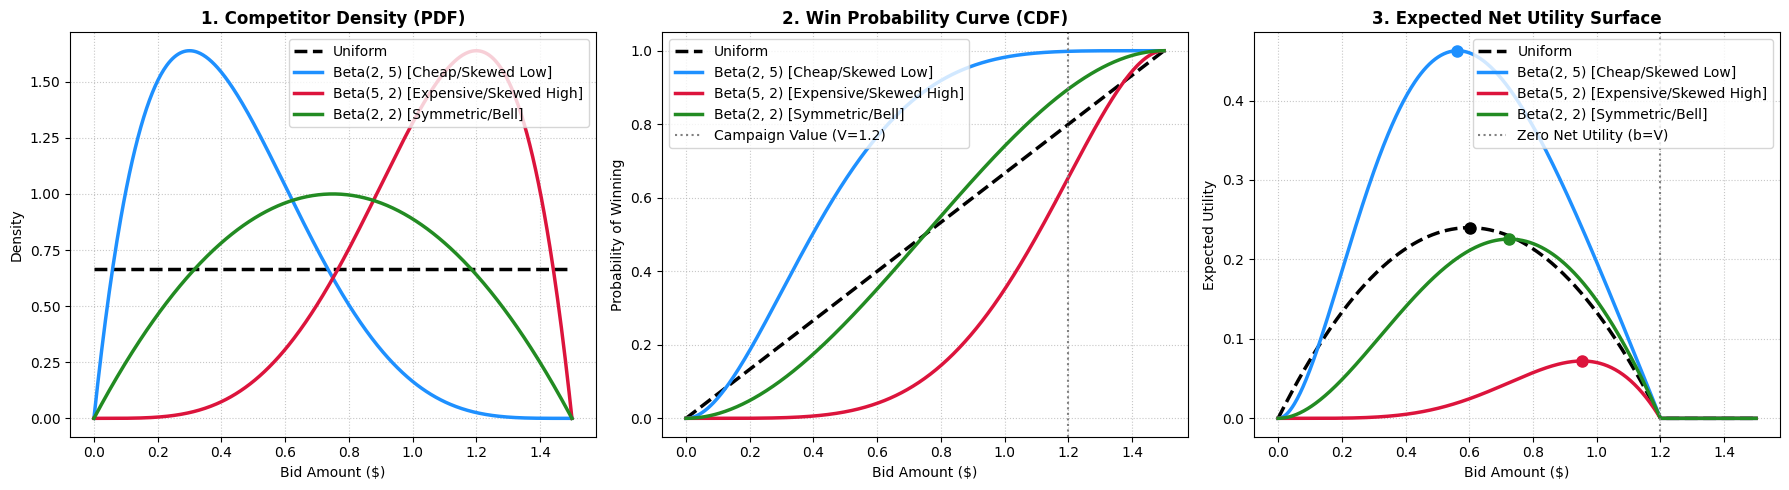

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, uniform

# ── 1. PARAMETERS ────────────────────────────────────────────────────────────
V = 1.2
COMPETITOR_MAX = 1.5
BIDS = np.linspace(0, COMPETITOR_MAX, 500)

# Beta Shapes
BETA_PARAMS = {
    "Beta(2, 5) [Cheap/Skewed Low]": (2, 5),
    "Beta(5, 2) [Expensive/Skewed High]": (5, 2),
    "Beta(2, 2) [Symmetric/Bell]": (2, 2)
}

# ── 2. COMPUTATION ───────────────────────────────────────────────────────────
distributions = {}

# Uniform Baseline
distributions["Uniform"] = {
    "pdf": uniform.pdf(BIDS, loc=0, scale=COMPETITOR_MAX),
    "cdf": uniform.cdf(BIDS, loc=0, scale=COMPETITOR_MAX)
}

# Beta Curves
for name, (a, b_param) in BETA_PARAMS.items():
    distributions[name] = {
        # Chain rule applied for scaled PDF: f(x) = (1/scale) * beta.pdf(x/scale, a, b)
        "pdf": beta.pdf(BIDS / COMPETITOR_MAX, a, b_param) / COMPETITOR_MAX,
        "cdf": beta.cdf(BIDS / COMPETITOR_MAX, a, b_param)
    }

# Expected Net Utility: E[U] = (V - b) * P(win)
# Clip (V - b) at 0 to avoid plotting negative utilities for irrational bids
for name in distributions:
    net_val = np.maximum(V - BIDS, 0.0)
    distributions[name]["exp_net"] = net_val * distributions[name]["cdf"]


# ── 3. PLOTTING ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['black', 'dodgerblue', 'crimson', 'forestgreen']
line_styles = ['--', '-', '-', '-']

# Plot 1: PDF (Where are the competitors?)
for (name, data), c, ls in zip(distributions.items(), colors, line_styles):
    axes[0].plot(BIDS, data["pdf"], label=name, color=c, linestyle=ls, lw=2.5)
axes[0].set_title("1. Competitor Density (PDF)", fontweight='bold')
axes[0].set_xlabel("Bid Amount ($)")
axes[0].set_ylabel("Density")
axes[0].grid(linestyle=':', alpha=0.7)
axes[0].legend()

# Plot 2: CDF / Win Probability (The Cost of Winning)
for (name, data), c, ls in zip(distributions.items(), colors, line_styles):
    axes[1].plot(BIDS, data["cdf"], label=name, color=c, linestyle=ls, lw=2.5)
axes[1].axvline(V, color='gray', linestyle=':', label="Campaign Value (V=1.2)")
axes[1].set_title("2. Win Probability Curve (CDF)", fontweight='bold')
axes[1].set_xlabel("Bid Amount ($)")
axes[1].set_ylabel("Probability of Winning")
axes[1].grid(linestyle=':', alpha=0.7)
axes[1].legend()

# Plot 3: Expected Net Utility (The True Optimization Target)
for (name, data), c, ls in zip(distributions.items(), colors, line_styles):
    axes[2].plot(BIDS, data["exp_net"], label=name, color=c, linestyle=ls, lw=2.5)
    
    # Mark the theoretical maximums (The Fluid Optimal Bids)
    max_idx = np.argmax(data["exp_net"])
    axes[2].plot(BIDS[max_idx], data["exp_net"][max_idx], marker='o', color=c, markersize=8)

axes[2].axvline(V, color='gray', linestyle=':', label="Zero Net Utility (b=V)")
axes[2].set_title("3. Expected Net Utility Surface", fontweight='bold')
axes[2].set_xlabel("Bid Amount ($)")
axes[2].set_ylabel("Expected Utility")
axes[2].grid(linestyle=':', alpha=0.7)
axes[2].legend()

plt.tight_layout()
plt.show()

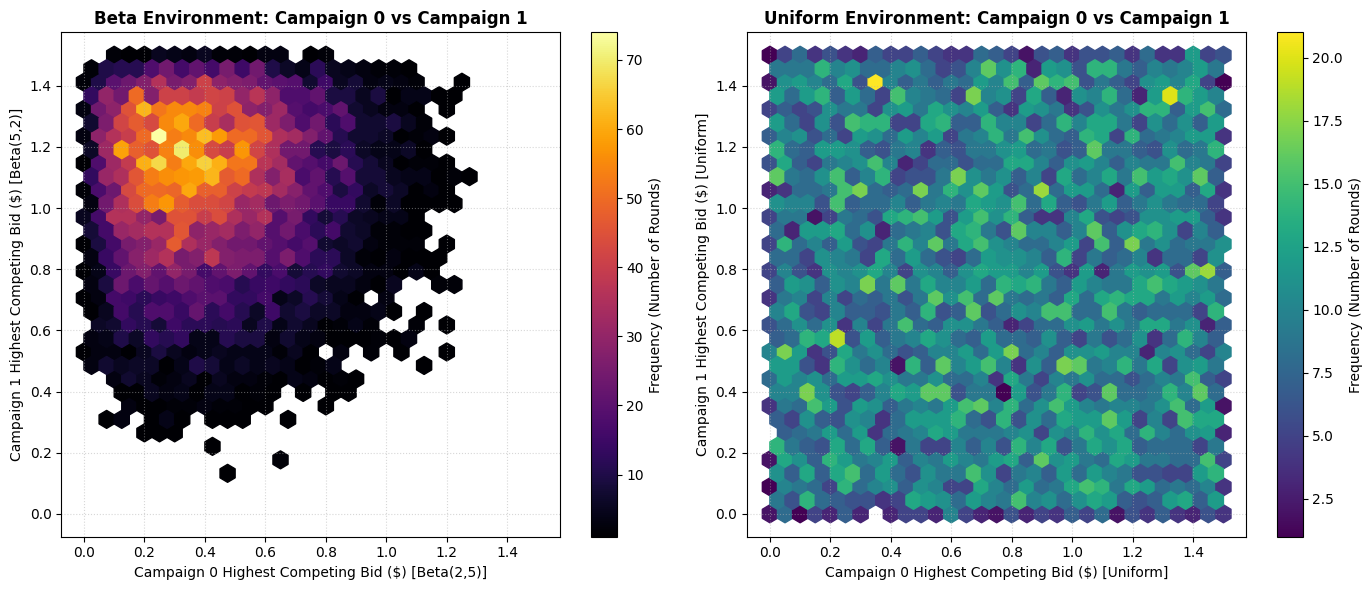

── Beta Environment Diagnostics ──
Camp 0 Mean: 0.428 | Theoretical: 0.429
Camp 1 Mean: 1.074 | Theoretical: 1.071
Empirical Covariance (C0, C1): 0.000188

── Uniform Environment Diagnostics ──
Camp 0 Mean: 0.761 | Theoretical: 0.750
Camp 1 Mean: 0.754 | Theoretical: 0.750
Empirical Covariance (C0, C1): 0.000050


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# ── 0. REPOSITORY IMPORTS ────────────────────────────────────────────────────
try:
    from src.multi_campign_environments import MultiCampaignEnvironment
except ImportError:
    raise ImportError("Execution failed. Ensure 'src' is accessible.")

# ── 1. INSTANCE DEFINITION ───────────────────────────────────────────────────
VALUES         = [1.2, 0.8, 1.0]
T              = 10000
B              = 0.3 * T  
COMPETITOR_MAX = 1.5

CONFLICT_MATRIX = [
    [False, True,  False],
    [True,  False, False],
    [False, False, False],
]

BETA_PARAMS = [(2, 5), (5, 2), (2, 2)]

# ── 2. JOINT DISTRIBUTION GENERATORS ─────────────────────────────────────────
def beta_joint_distribution(size):
    """Independent Beta marginals."""
    seq = np.zeros((size, len(VALUES)))
    for i in range(len(VALUES)):
        a, b_param = BETA_PARAMS[i]
        seq[:, i] = np.random.beta(a, b_param, size=size) * COMPETITOR_MAX
    return seq

def uniform_joint_distribution(size):
    """Independent Uniform marginals."""
    return np.random.uniform(0.0, COMPETITOR_MAX, size=(size, len(VALUES)))

# Dummy CDF list (Not used for physical sequence generation, just to satisfy the class signature)
dummy_cdfs = [lambda x: x]*3 

# ── 3. ENVIRONMENT INSTANTIATION ─────────────────────────────────────────────
np.random.seed(42)

env_beta = MultiCampaignEnvironment(
    VALUES, B, T, beta_joint_distribution, CONFLICT_MATRIX, dummy_cdfs
)

env_uniform = MultiCampaignEnvironment(
    VALUES, B, T, uniform_joint_distribution, CONFLICT_MATRIX, dummy_cdfs
)

# Extract the physical stochastic sequences
seq_beta = env_beta.m_sequence
seq_uniform = env_uniform.m_sequence

# ── 4. BIVARIATE DENSITY PLOTTING ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Define grid limits
grid_extent = [0, COMPETITOR_MAX, 0, COMPETITOR_MAX]

# 1. Beta Joint Density
hb1 = axes[0].hexbin(
    seq_beta[:, 0], seq_beta[:, 1], 
    gridsize=30, cmap='inferno', mincnt=1, extent=grid_extent
)
axes[0].set_title("Beta Environment: Campaign 0 vs Campaign 1", fontweight='bold')
axes[0].set_xlabel("Campaign 0 Highest Competing Bid ($) [Beta(2,5)]")
axes[0].set_ylabel("Campaign 1 Highest Competing Bid ($) [Beta(5,2)]")
cb1 = fig.colorbar(hb1, ax=axes[0])
cb1.set_label("Frequency (Number of Rounds)")
axes[0].grid(linestyle=':', alpha=0.5)

# 2. Uniform Joint Density
hb2 = axes[1].hexbin(
    seq_uniform[:, 0], seq_uniform[:, 1], 
    gridsize=30, cmap='viridis', mincnt=1, extent=grid_extent
)
axes[1].set_title("Uniform Environment: Campaign 0 vs Campaign 1", fontweight='bold')
axes[1].set_xlabel("Campaign 0 Highest Competing Bid ($) [Uniform]")
axes[1].set_ylabel("Campaign 1 Highest Competing Bid ($) [Uniform]")
cb2 = fig.colorbar(hb2, ax=axes[1])
cb2.set_label("Frequency (Number of Rounds)")
axes[1].grid(linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# ── 5. STATISTICAL DIAGNOSTICS ───────────────────────────────────────────────
print("── Beta Environment Diagnostics ──")
print(f"Camp 0 Mean: {np.mean(seq_beta[:, 0]):.3f} | Theoretical: {COMPETITOR_MAX * (2/(2+5)):.3f}")
print(f"Camp 1 Mean: {np.mean(seq_beta[:, 1]):.3f} | Theoretical: {COMPETITOR_MAX * (5/(5+2)):.3f}")
print(f"Empirical Covariance (C0, C1): {np.cov(seq_beta[:, 0], seq_beta[:, 1])[0,1]:.6f}")

print("\n── Uniform Environment Diagnostics ──")
print(f"Camp 0 Mean: {np.mean(seq_uniform[:, 0]):.3f} | Theoretical: {COMPETITOR_MAX / 2:.3f}")
print(f"Camp 1 Mean: {np.mean(seq_uniform[:, 1]):.3f} | Theoretical: {COMPETITOR_MAX / 2:.3f}")
print(f"Empirical Covariance (C0, C1): {np.cov(seq_uniform[:, 0], seq_uniform[:, 1])[0,1]:.6f}")

## Visualizing the Conflict Matrix : 

Function to visualize the conflict matrix : 

In [77]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def plot_conflict_graph(M) -> None:
    M =  np.array(M) 
    if M.ndim != 2 or M.shape[0] != M.shape[1]:
        raise ValueError("Matrix must be square.")
    if M.dtype != bool:
        raise TypeError("Matrix must be boolean.")
    if not np.array_equal(M, M.T):
        raise ValueError("Conflict matrix must be symmetric.")

    G = nx.from_numpy_array(M)
    
    plt.figure(figsize=(6, 6))
    nx.draw(
        G, 
        nx.spring_layout(G, seed=42), 
        with_labels=True, 
        node_color='lightcoral', 
        edge_color='black', 
        node_size=800, 
        font_weight='bold'
    )
    plt.title("Conflict Graph")
    plt.show()

Test on some instances 

In [78]:
import numpy as np

# Dimension 4
M_4 = np.array([
    [False, True,  False, False],
    [True,  False, True,  False],
    [False, True,  False, True ],
    [False, False, True,  False]
])

# Dimension 10
M_10 = np.array([
    [False, True,  False, False, True,  False, False, False, False, False],
    [True,  False, True,  False, False, True,  False, False, False, False],
    [False, True,  False, True,  False, False, True,  False, False, False],
    [False, False, True,  False, True,  False, False, True,  False, False],
    [True,  False, False, True,  False, False, False, False, True,  False],
    [False, True,  False, False, False, False, True,  False, False, True ],
    [False, False, True,  False, False, True,  False, True,  False, False],
    [False, False, False, True,  False, False, True,  False, True,  False],
    [False, False, False, False, True,  False, False, True,  False, True ],
    [False, False, False, False, False, True,  False, False, True,  False]
])

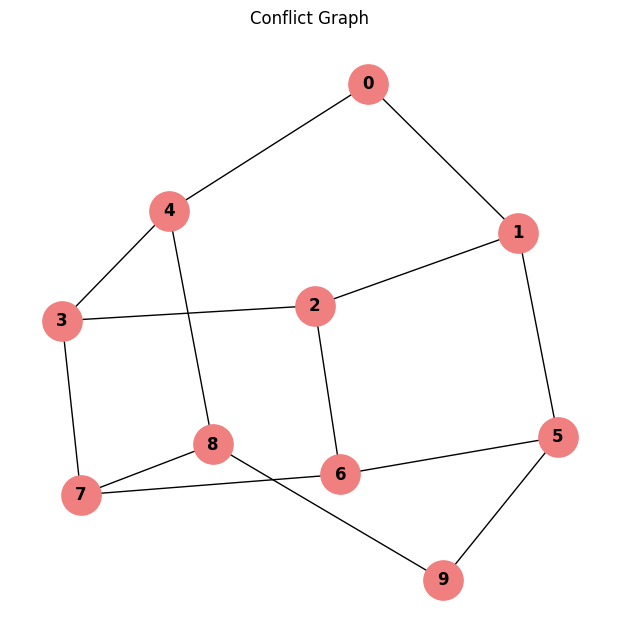

In [79]:
plot_conflict_graph(M_10)

# Extension of UCB for multiple campaigns : 

In [118]:
from src.multi_campign_learners import C_UCB_Bidding, LP_agent, LP_MeanCost_agent, ARGMAX_agent

In [121]:
import numpy as np

# --- EXECUTION HARNESS ---
if __name__ == "__main__":
    values = [1.2, 0.8, 2.0]
    bid_space = [0.0, 0.5, 1.0, 1.5]
    T = 100
    B = 0.4 * T  # Tight budget to force pacing limit engagement

    conflict_matrix = [
        [False, True,  False],
        [True,  False, False],
        [False, False, False]
    ]

    print("--- Initialization ---")
    # Swap class name here to test LP_agent or ARGMAX_agent
    agent = LP_agent(values, bid_space, B, T, conflict_matrix)
    print(f"Action Space: {agent.M} valid independent sets.\n")

    np.random.seed(42) 

    for t in range(1, T + 1):
        bids = agent.pull_arm()
        competitor_m = np.random.uniform(0.0, 1.5, size=agent.N)
        
        if agent.budget - agent.spent < 1.0:
            won_vector = np.zeros(agent.N, dtype=bool)
            util_vector = np.zeros(agent.N)
            cost_vector = np.zeros(agent.N)
            print(f"Round {t}: BUDGET DEPLETED.")
        else:
            won_vector = bids >= competitor_m
            cost_vector = np.where(won_vector, bids, 0.0)
            util_vector = np.where(won_vector, np.array(values) - bids, 0.0)
            
        agent.update(won_vector, util_vector, cost_vector)
        
        rho_t = (agent.budget - agent.spent) / np.maximum(T - agent.t, 1.0)
        print(f"Round {t}/{T} | Pacing Limit (rho_t): {rho_t:.2f} | Spent: {agent.spent:.2f}/{B}")
        print(f"  Selected Bids : {bids}")
        print(f"  Win Vector    : {won_vector}")
        print(f"  Utility/Cost  : {np.sum(util_vector):.2f} / {np.sum(cost_vector):.2f}")
        print("-" * 50)

--- Initialization ---
Action Space: 16 valid independent sets.

Round 1/100 | Pacing Limit (rho_t): 0.40 | Spent: 0.00/40.0
  Selected Bids : [0.5 0.  0.5]
  Win Vector    : [False False False]
  Utility/Cost  : 0.00 / 0.00
--------------------------------------------------
Round 2/100 | Pacing Limit (rho_t): 0.40 | Spent: 0.50/40.0
  Selected Bids : [0.5 0.  0.5]
  Win Vector    : [ True False False]
  Utility/Cost  : 0.70 / 0.50
--------------------------------------------------
Round 3/100 | Pacing Limit (rho_t): 0.41 | Spent: 0.50/40.0
  Selected Bids : [0.5 0.  0.5]
  Win Vector    : [False False False]
  Utility/Cost  : 0.00 / 0.00
--------------------------------------------------
Round 4/100 | Pacing Limit (rho_t): 0.40 | Spent: 2.00/40.0
  Selected Bids : [0.5 0.  1. ]
  Win Vector    : [ True False  True]
  Utility/Cost  : 1.70 / 1.50
--------------------------------------------------
Round 5/100 | Pacing Limit (rho_t): 0.39 | Spent: 2.50/40.0
  Selected Bids : [0.5 0.  0.5]

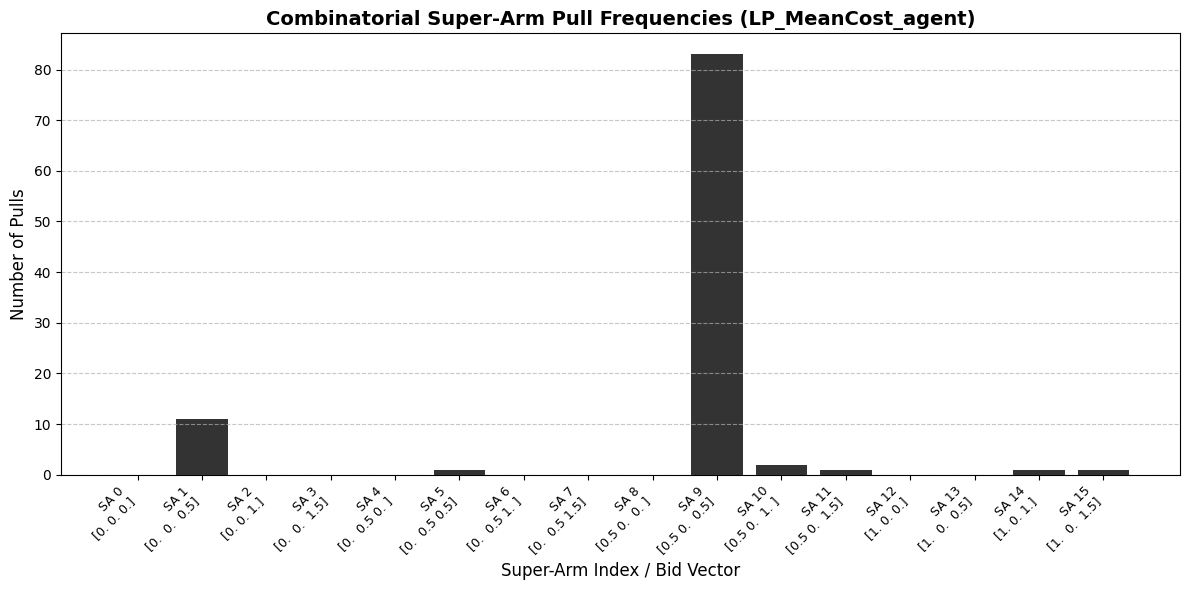

In [123]:
import numpy as np
import matplotlib.pyplot as plt

# --- EXECUTION HARNESS ---
if __name__ == "__main__":
    values = [1.2, 0.8, 2.0]
    bid_space = [0.0, 0.5, 1.0, 1.5]
    T = 100
    B = 0.4 * T

    conflict_matrix = [
        [False, True,  False],
        [True,  False, False],
        [False, False, False]
    ]

    # Instantiate the patched, stable architecture
    agent = LP_MeanCost_agent(values, bid_space, B, T, conflict_matrix)
    np.random.seed(42) 
    
    # ── EXTERNAL COMBINATORIAL TRACKING ──
    # Prevents needing to re-inject tracking variables into the agent classes
    sa_pull_counts = np.zeros(agent.M, dtype=int)

    for t in range(1, T + 1):
        bids = agent.pull_arm()
        competitor_m = np.random.uniform(0.0, 1.5, size=agent.N)
        
        # Reverse map the chosen indices to the super-arm matrix
        chosen_sa_idx = np.where((agent.super_arms == agent.last_action_indices).all(axis=1))[0][0]
        sa_pull_counts[chosen_sa_idx] += 1
        
        if agent.budget - agent.spent < 1.0:
            won_vector = np.zeros(agent.N, dtype=bool)
            util_vector = np.zeros(agent.N)
            cost_vector = np.zeros(agent.N)
        else:
            won_vector = bids >= competitor_m
            cost_vector = np.where(won_vector, bids, 0.0)
            # ── STRICT ENFORCEMENT: Net Utility ──
            util_vector = np.where(won_vector, np.array(values) - bids, 0.0)
            
        agent.update(won_vector, util_vector, cost_vector)

    # --- Plotting Subroutine ---
    plt.figure(figsize=(12, 6))
    
    # Generate readable string labels for each super-arm
    sa_labels = [f"SA {i}\n{agent.bid_space[sa]}" for i, sa in enumerate(agent.super_arms)]
    
    plt.bar(range(agent.M), sa_pull_counts, color='black', alpha=0.8)
    
    plt.title("Combinatorial Super-Arm Pull Frequencies (LP_MeanCost_agent)", fontsize=14, fontweight='bold')
    plt.xlabel("Super-Arm Index / Bid Vector", fontsize=12)
    plt.ylabel("Number of Pulls", fontsize=12)
    plt.xticks(range(agent.M), sa_labels, rotation=45, ha='right', fontsize=9)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Total net utility : 343.40
Total spent       : 201.00 / 200.00
Super-arms found  : 16


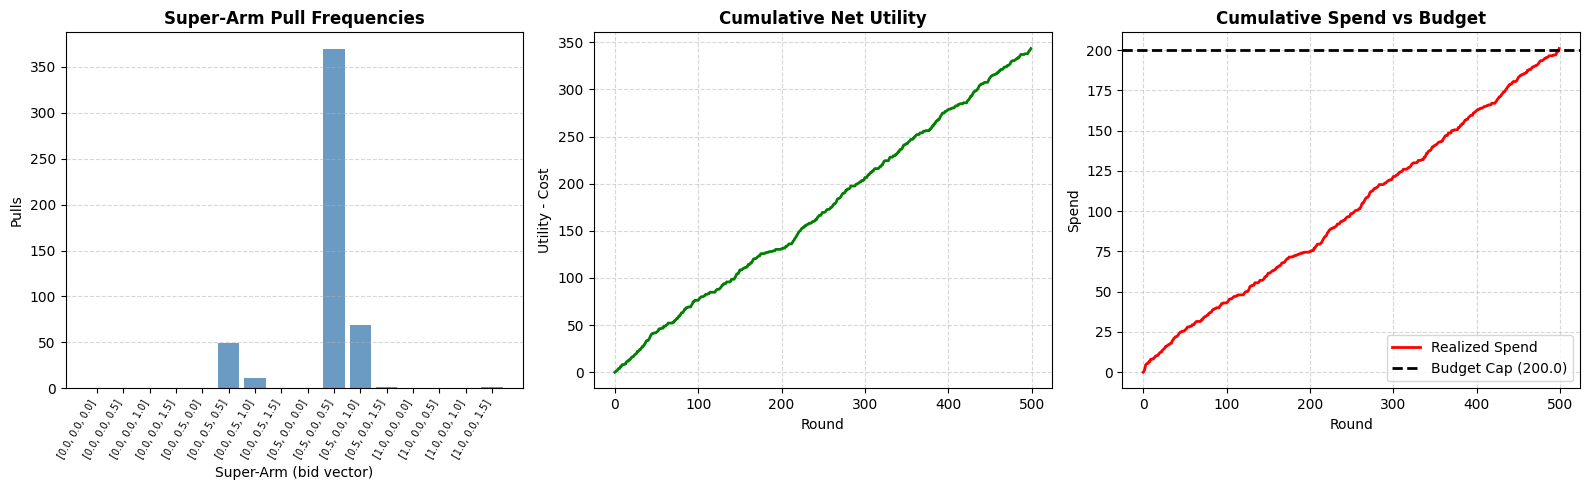

In [124]:
import numpy as np
import matplotlib.pyplot as plt

# --- EXECUTION HARNESS ---
if __name__ == "__main__":
    values = [1.2, 0.8, 2.0]
    bid_space = [0.0, 0.5, 1.0, 1.5]
    T = 500
    B = 0.4 * T
    
    conflict_matrix = [
        [False, True,  False],
        [True,  False, False],
        [False, False, False]
    ]

    # Instantiate the patched, stable architecture
    agent = LP_MeanCost_agent(values, bid_space, B, T, conflict_matrix)
    np.random.seed(42) 
    
    # Tracking arrays
    sa_pull_counts = np.zeros(agent.M, dtype=int)
    cumulative_utility = np.zeros(T)
    cumulative_spend = np.zeros(T)
    
    total_utility = 0.0

    for t in range(T):
        bids = agent.pull_arm()
        competitor_m = np.random.uniform(0.0, 1.5, size=agent.N)
        
        # O(1) Vectorized Reverse Mapping
        chosen_sa_idx = np.where((agent.super_arms == agent.last_action_indices).all(axis=1))[0][0]
        sa_pull_counts[chosen_sa_idx] += 1
        
        # Strict Environmental Firewall
        if agent.budget - agent.spent < 1e-6:
            won_vector = np.zeros(agent.N, dtype=bool)
            util_vector = np.zeros(agent.N)
            cost_vector = np.zeros(agent.N)
        else:
            won_vector = bids >= competitor_m
            cost_vector = np.where(won_vector, bids, 0.0)
            # STRICT ENFORCEMENT: Net Utility
            util_vector = np.where(won_vector, np.array(values) - bids, 0.0)
            
        agent.update(won_vector, util_vector, cost_vector)
        
        total_utility += np.sum(util_vector)
        cumulative_utility[t] = total_utility
        cumulative_spend[t] = agent.spent

    print(f"Total net utility : {total_utility:.2f}")
    print(f"Total spent       : {agent.spent:.2f} / {B:.2f}")
    print(f"Super-arms found  : {agent.M}")

    # --- Plotting Subroutine ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # 1. Super-arm pull frequencies
    sa_labels = [str(agent.bid_space[sa].tolist()) for sa in agent.super_arms]
    axes[0].bar(range(agent.M), sa_pull_counts, color='steelblue', alpha=0.8)
    axes[0].set_title("Super-Arm Pull Frequencies", fontweight='bold')
    axes[0].set_xlabel("Super-Arm (bid vector)")
    axes[0].set_ylabel("Pulls")
    axes[0].set_xticks(range(agent.M))
    axes[0].set_xticklabels(sa_labels, rotation=60, ha='right', fontsize=7)
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    # 2. Cumulative net utility
    axes[1].plot(cumulative_utility, color='green', lw=2)
    axes[1].set_title("Cumulative Net Utility", fontweight='bold')
    axes[1].set_xlabel("Round")
    axes[1].set_ylabel("Utility - Cost")
    axes[1].grid(linestyle='--', alpha=0.5)

    # 3. Budget spend over time
    axes[2].plot(cumulative_spend, color='red', lw=2, label='Realized Spend')
    axes[2].axhline(B, color='black', linestyle='--', lw=2, label=f'Budget Cap ({B})')
    axes[2].set_title("Cumulative Spend vs Budget", fontweight='bold')
    axes[2].set_xlabel("Round")
    axes[2].set_ylabel("Spend")
    axes[2].legend()
    axes[2].grid(linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

Let's compute the baseline clairvoyant : 

In [14]:
def compute_clairvoyant(values, bid_space, B, T, conflict_matrix, cdf_functions):
    values = np.array(values, dtype=float)
    bid_space = np.array(bid_space, dtype=float)
    N, K = len(values), len(bid_space)
    rho = float(B) / float(T)

    # Injecting the distinct CDFs
    win_prob = np.zeros((N, K))
    for i in range(N):
        win_prob[i, :] = cdf_functions[i](bid_space)
    
    win_prob = np.clip(win_prob, 0.0, 1.0)

    # Net Expectations
    mu_f = (values[:, None] - bid_space[None, :]) * win_prob
    mu_c = bid_space[None, :] * win_prob

    # Pinning Inactivity
    mu_f[:, 0] = 0.0
    mu_c[:, 0] = 0.0

    valid_per_campaign = [[k for k, b in enumerate(bid_space) if b <= values[i]] for i in range(N)]
    valid_arms = []
    for combo in itertools.product(*valid_per_campaign):
        conflict = False
        for i in range(N):
            for j in range(i + 1, N):
                if conflict_matrix[i][j] and combo[i] != 0 and combo[j] != 0:
                    conflict = True
                    break
            if conflict: break
        if not conflict: valid_arms.append(combo)

    super_arms = np.array(valid_arms, dtype=int)
    M = len(super_arms)

    idx = np.arange(N)[None, :]
    U_sa = np.sum(mu_f[idx, super_arms], axis=1)
    C_sa = np.sum(mu_c[idx, super_arms], axis=1)

    res = optimize.linprog(
        -U_sa, A_ub=C_sa.reshape(1, -1), b_ub=np.array([rho]),
        A_eq=np.ones((1, M)), b_eq=np.array([1.0]),
        bounds=[(0.0, 1.0)] * M, method='highs-ds'
    )
    
    if not res.success:
        raise ValueError(f"Fluid LP failed: {res.message}")
        
    gamma = np.clip(res.x, 0.0, 1.0)
    gamma /= gamma.sum()
    net_per_round = float(np.dot(gamma, U_sa))
    
    return gamma, super_arms, net_per_round


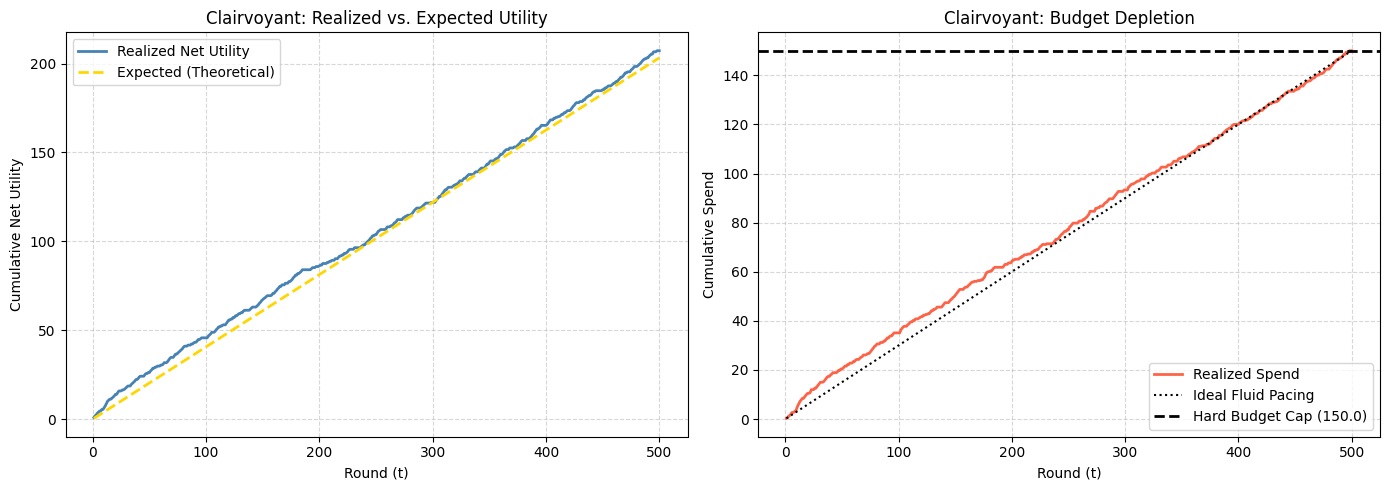

Optimal Expected Net Utility / Round : 0.4064
Final Realized Net Utility           : 207.20
Final Realized Spend                 : 150.00 / 150.0


In [15]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
from scipy import optimize
from scipy.stats import beta

# ── 1. INSTANCE DEFINITION ───────────────────────────────────────────────────
VALUES         = [1.2, 0.8, 1.0]
BID_SPACE      = [0.0, 0.3, 0.6, 0.9, 1.2]
T              = 500
B              = 0.3 * T  # Budget designed to force fractional pacing
COMPETITOR_MAX = 1.5
SEED           = 42

CONFLICT_MATRIX = [
    [False, True,  False],
    [True,  False, False],
    [False, False, False],
]

# Beta shape parameters: (alpha, beta)
# Camp 0: Beta(2,5) -> Skewed low (cheap to win)
# Camp 1: Beta(5,2) -> Skewed high (expensive to win)
# Camp 2: Beta(2,2) -> Symmetric
BETA_PARAMS = [(2, 5), (5, 2), (10, 8)]

# Decoupled CDF functions for the Oracle
def cdf_0(bids): return beta.cdf(np.clip(bids / COMPETITOR_MAX, 0.0, 1.0), 2, 5)
def cdf_1(bids): return beta.cdf(np.clip(bids / COMPETITOR_MAX, 0.0, 1.0), 5, 2)
def cdf_2(bids): return beta.cdf(np.clip(bids / COMPETITOR_MAX, 0.0, 1.0), 10, 8)

CDF_LIST = [cdf_0, cdf_1, cdf_2]



# ── 3. EMPIRICAL SIMULATION LOOP ─────────────────────────────────────────────
def run_clairvoyant_simulation():
    gamma, super_arms, expected_net_per_round = compute_clairvoyant(
        VALUES, BID_SPACE, B, T, CONFLICT_MATRIX, CDF_LIST
    )
    
    np.random.seed(SEED)
    
    spent = 0.0
    total_net = 0.0
    
    cum_utility  = np.zeros(T)
    cum_spend    = np.zeros(T)
    cum_expected = np.zeros(T)

    for t in range(T):
        # 1. Oracle acts strictly according to stationary distribution gamma
        m = np.random.choice(len(super_arms), p=gamma)
        chosen_bids = np.array(BID_SPACE)[super_arms[m]]
        
        # 2. Environment draws specific Beta realizations
        competitor = np.zeros(len(VALUES))
        for i in range(len(VALUES)):
            a, b_param = BETA_PARAMS[i]
            competitor[i] = np.random.beta(a, b_param) * COMPETITOR_MAX
            
        # 3. Knapsack Firewall
        cost_proposal = np.where(chosen_bids >= competitor, chosen_bids, 0.0)
        if spent + np.sum(cost_proposal) > B:
            cost = np.zeros(len(VALUES))
            util = np.zeros(len(VALUES))
        else:
            won = chosen_bids >= competitor
            cost = cost_proposal
            util = np.where(won, np.array(VALUES) - chosen_bids, 0.0)
            
        # 4. Accounting
        spent += np.sum(cost)
        total_net += np.sum(util)
        
        cum_utility[t] = total_net
        cum_spend[t]   = spent
        cum_expected[t] = expected_net_per_round * (t + 1)
        
    return cum_utility, cum_spend, cum_expected, expected_net_per_round, spent

# ── 4. PLOTTING ──────────────────────────────────────────────────────────────
cum_utility, cum_spend, cum_expected, opt_rate, final_spend = run_clairvoyant_simulation()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rounds = np.arange(1, T + 1)

# Plot 1: Utility Tracking
axes[0].plot(rounds, cum_utility, color='steelblue', lw=2, label='Realized Net Utility')
axes[0].plot(rounds, cum_expected, color='gold', lw=2, linestyle='--', label=f'Expected (Theoretical)')
axes[0].set_title("Clairvoyant: Realized vs. Expected Utility")
axes[0].set_xlabel("Round (t)")
axes[0].set_ylabel("Cumulative Net Utility")
axes[0].legend()
axes[0].grid(linestyle='--', alpha=0.5)

# Plot 2: Budget Tracking
axes[1].plot(rounds, cum_spend, color='tomato', lw=2, label='Realized Spend')
axes[1].plot(rounds, (B/T)*rounds, color='black', lw=1.5, linestyle=':', label='Ideal Fluid Pacing')
axes[1].axhline(B, color='black', lw=2, linestyle='--', label=f'Hard Budget Cap ({B})')
axes[1].set_title("Clairvoyant: Budget Depletion")
axes[1].set_xlabel("Round (t)")
axes[1].set_ylabel("Cumulative Spend")
axes[1].legend()
axes[1].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Optimal Expected Net Utility / Round : {opt_rate:.4f}")
print(f"Final Realized Net Utility           : {cum_utility[-1]:.2f}")
print(f"Final Realized Spend                 : {final_spend:.2f} / {B}")

In [23]:
# ── INSTANCE PARAMETERS ───────────────────────────────────────────────────────
VALUES         = [0.75, 0.8, 0.7]
BID_SPACE      = [0.0, 0.3, 0.6, 0.9, 1.2]
T              = 20000
B              = 0.2 * T 
COMPETITOR_MAX = 1
SEED           = 42
CONFLICT       = [
    [False, True,  False],
    [True,  False, False],
    [False, False, False],
]

import numpy as np

# ── 1. UNIFORM DISTRIBUTION DEFINITION ───────────────────────────────────────
COMPETITOR_MAX = 1.0  # Adjusted to your new parameter

# Define the Universal Uniform CDF
def uniform_cdf(bids): 
    return np.clip(bids / COMPETITOR_MAX, 0.0, 1.0)

# Pass the identical CDF for all campaigns
CDF_LIST = [uniform_cdf, uniform_cdf, uniform_cdf]

# Define the Uniform Joint Distribution Generator for the Environment
def uniform_joint_distribution(size):
    return np.random.uniform(0.0, COMPETITOR_MAX, size=(size, len(VALUES)))

# ── 2. EXECUTION SETUP ───────────────────────────────────────────────────────
np.random.seed(SEED)

# Use the decoupled Oracle
_, _, opt_net_per_round = compute_clairvoyant(
    VALUES, BID_SPACE, B, T, CONFLICT, CDF_LIST
)

# Use the mathematically stable agents
agents = {
    "LP_MeanCost": LP_MeanCost_agent(VALUES, BID_SPACE, B, T, CONFLICT),
    "Greedy": ARGMAX_agent(VALUES, BID_SPACE, B, T, CONFLICT)
}

# Instantiate strictly encapsulated environments
envs = {
    name: MultiCampaignEnvironment(
        VALUES, B, T, uniform_joint_distribution, CONFLICT, CDF_LIST
    )
    for name in agents
}

results = {name: {"pseudo_regret": np.zeros(T), "util": np.zeros(T), "spend": np.zeros(T)} for name in agents}

# ── 3. ENCAPSULATED SIMULATION LOOP ──────────────────────────────────────────
for t in range(T):
    for name, agent in agents.items():
        bids = agent.pull_arm()
        
        # Absolute physical reality and mathematical tracking dictated by the Environment
        won_vector, util_vector, cost_vector, info = envs[name].resolve_auction(bids)
        
        agent.update(won_vector, util_vector, cost_vector)
        
        # Record metrics using the exact theoretical expectation provided by the Environment
        results[name]["pseudo_regret"][t] = opt_net_per_round - info["expected_net"]
        results[name]["util"][t] = np.sum(util_vector)
        results[name]["spend"][t] = envs[name].spent


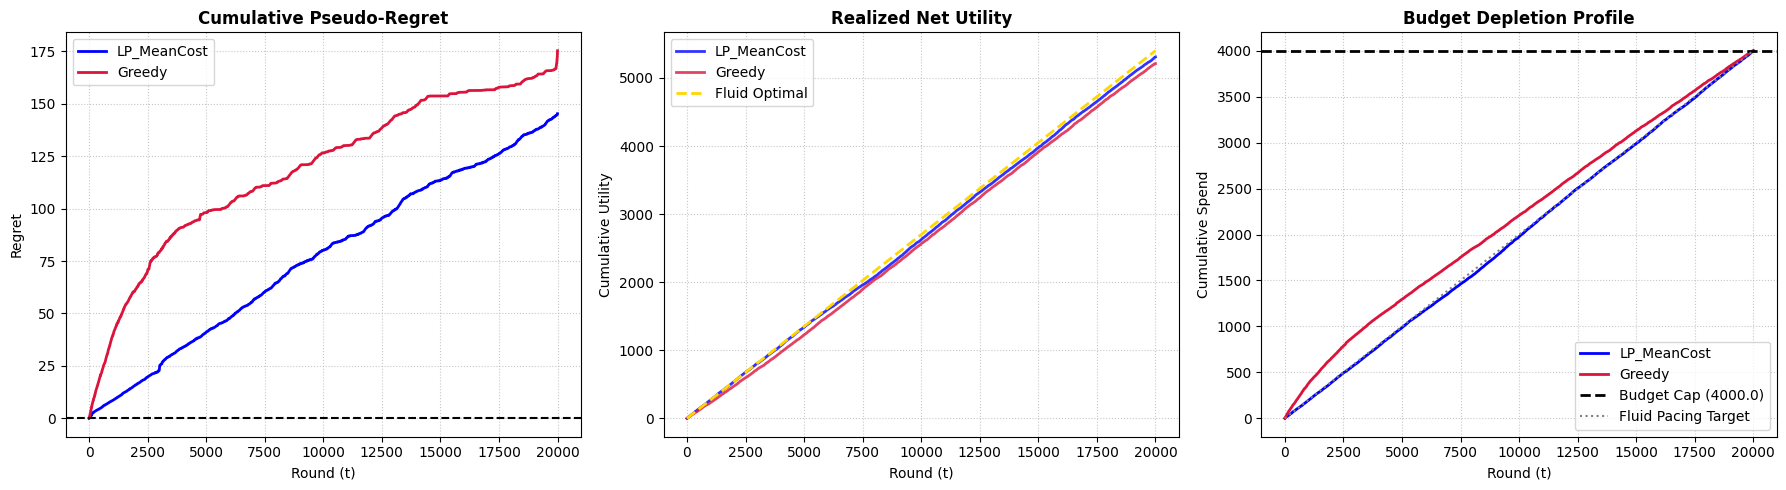


Agent                     | Final Pseudo-Regret  | Final Spend    
-----------------------------------------------------------------
LP_MeanCost               | 145.21               | 3999.30/4000.00
Greedy                    | 175.26               | 3999.90/4000.00


In [24]:
# ── 4. PLOTTING ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
rounds = np.arange(1, T + 1)

# Dynamic color mapping to prevent KeyErrors
palette = ['blue', 'crimson', 'forestgreen', 'darkorange', 'purple']
colors = {name: palette[i % len(palette)] for i, name in enumerate(agents.keys())}

# 1. Cumulative Pseudo-Regret
for name in agents:
    axes[0].plot(rounds, np.cumsum(results[name]["pseudo_regret"]), color=colors[name], lw=2, label=name)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title("Cumulative Pseudo-Regret", fontweight='bold')
axes[0].set_xlabel("Round (t)")
axes[0].set_ylabel("Regret")
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.7)

# 2. Cumulative Realized Net Utility
for name in agents:
    axes[1].plot(rounds, np.cumsum(results[name]["util"]), color=colors[name], lw=2, alpha=0.8, label=name)
axes[1].plot(rounds, opt_net_per_round * rounds, color='gold', lw=2, linestyle='--', label="Fluid Optimal")
axes[1].set_title("Realized Net Utility", fontweight='bold')
axes[1].set_xlabel("Round (t)")
axes[1].set_ylabel("Cumulative Utility")
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)

# 3. Budget Depletion
for name in agents:
    axes[2].plot(rounds, results[name]["spend"], color=colors[name], lw=2, label=name)
axes[2].axhline(B, color='black', lw=2, linestyle='--', label=f"Budget Cap ({B})")
# RESTORED: The mandatory pacing diagnostic
axes[2].plot(rounds, (B/T)*rounds, color='gray', lw=1.5, linestyle=':', label="Fluid Pacing Target")
axes[2].set_title("Budget Depletion Profile", fontweight='bold')
axes[2].set_xlabel("Round (t)")
axes[2].set_ylabel("Cumulative Spend")
axes[2].legend()
axes[2].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# Print diagnostics
print(f"\n{'Agent':<25} | {'Final Pseudo-Regret':<20} | {'Final Spend':<15}")
print("-" * 65)
for name in agents:
    final_regret = np.sum(results[name]['pseudo_regret'])
    final_spend = results[name]['spend'][-1]
    print(f"{name:<25} | {final_regret:<20.2f} | {final_spend:.2f}/{B:.2f}")

Simulating T=20000. Evaluating...


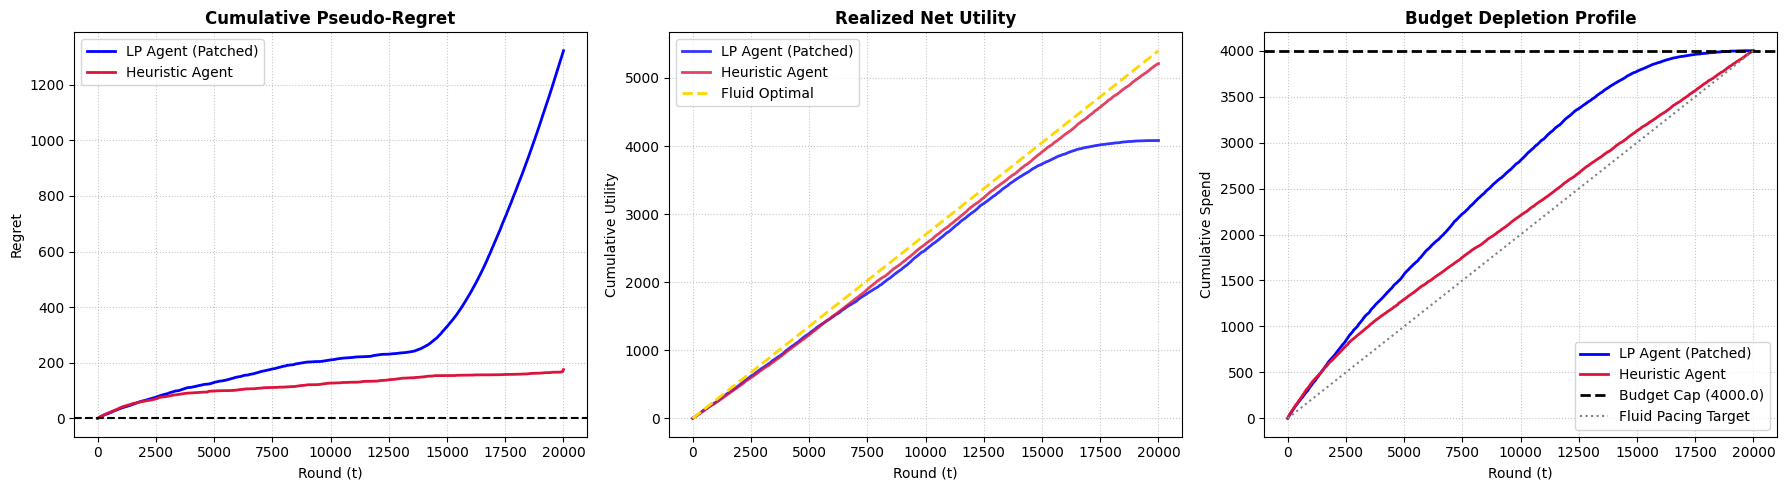


Agent                     | Final Pseudo-Regret  | Final Spend    
-----------------------------------------------------------------
LP Agent (Patched)        | 1322.08              | 3999.90/4000.00
Heuristic Agent           | 175.26               | 3999.90/4000.00


In [22]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
from scipy import optimize

# ── 0. REPOSITORY IMPORTS ────────────────────────────────────────────────────
try:
    from src.multi_campign_learners import LP_MeanCost_agent, ARGMAX_agent
    from src.multi_campign_environments import MultiCampaignEnvironment
except ImportError:
    raise ImportError("Execution failed. Ensure 'src' is accessible.")

# ── 1. INSTANCE PARAMETERS ───────────────────────────────────────────────────
VALUES         = [0.75, 0.8, 0.7]
BID_SPACE      = [0.0, 0.3, 0.6, 0.9, 1.2]
T              = 20000
B              = 0.2 * T 
COMPETITOR_MAX = 1.0
SEED           = 42
CONFLICT       = [
    [False, True,  False],
    [True,  False, False],
    [False, False, False],
]

# ── 2. UNIFORM DISTRIBUTION SETUP ────────────────────────────────────────────
def uniform_cdf(bids): 
    return np.clip(bids / COMPETITOR_MAX, 0.0, 1.0)

CDF_LIST = [uniform_cdf, uniform_cdf, uniform_cdf]

def uniform_joint_distribution(size):
    return np.random.uniform(0.0, COMPETITOR_MAX, size=(size, len(VALUES)))

# ── 3. CLAIRVOYANT ORACLE ────────────────────────────────────────────────────
def compute_clairvoyant(values, bid_space, B, T, conflict_matrix, cdf_functions):
    values = np.array(values, dtype=float)
    bid_space = np.array(bid_space, dtype=float)
    N, K = len(values), len(bid_space)
    rho = float(B) / float(T)

    win_prob = np.zeros((N, K))
    for i in range(N):
        win_prob[i, :] = cdf_functions[i](bid_space)
    win_prob = np.clip(win_prob, 0.0, 1.0)

    mu_f = (values[:, None] - bid_space[None, :]) * win_prob
    mu_c = bid_space[None, :] * win_prob
    mu_f[:, 0] = 0.0
    mu_c[:, 0] = 0.0

    valid_per_campaign = [[k for k, b in enumerate(bid_space) if b <= values[i]] for i in range(N)]
    valid_arms = []
    for combo in itertools.product(*valid_per_campaign):
        conflict = False
        for i in range(N):
            for j in range(i + 1, N):
                if conflict_matrix[i][j] and combo[i] != 0 and combo[j] != 0:
                    conflict = True
                    break
            if conflict: break
        if not conflict: valid_arms.append(combo)

    super_arms = np.array(valid_arms, dtype=int)
    M = len(super_arms)
    idx = np.arange(N)[None, :]
    U_sa = np.sum(mu_f[idx, super_arms], axis=1)
    C_sa = np.sum(mu_c[idx, super_arms], axis=1)

    res = optimize.linprog(
        -U_sa, A_ub=C_sa.reshape(1, -1), b_ub=np.array([rho]),
        A_eq=np.ones((1, M)), b_eq=np.array([1.0]),
        bounds=[(0.0, 1.0)] * M, method='highs-ds'
    )
    
    if not res.success: raise ValueError("Fluid LP failed")
    gamma = np.clip(res.x, 0.0, 1.0)
    gamma /= gamma.sum()
    return gamma, super_arms, float(np.dot(gamma, U_sa))

# ── 4. EXECUTION SETUP ───────────────────────────────────────────────────────
if __name__ == "__main__":
    np.random.seed(SEED)
    _, _, opt_net_per_round = compute_clairvoyant(VALUES, BID_SPACE, B, T, CONFLICT, CDF_LIST)

    agents = {
        "LP Agent (Patched)": LP_agent(VALUES, BID_SPACE, B, T, CONFLICT),
        "Heuristic Agent": ARGMAX_agent(VALUES, BID_SPACE, B, T, CONFLICT)
    }

    envs = {
        name: MultiCampaignEnvironment(VALUES, B, T, uniform_joint_distribution, CONFLICT, CDF_LIST)
        for name in agents
    }

    results = {name: {"pseudo_regret": np.zeros(T), "util": np.zeros(T), "spend": np.zeros(T)} for name in agents}
    print(f"Simulating T={T}. Evaluating...")

    # ── 5. ENCAPSULATED SIMULATION LOOP ──────────────────────────────────────────
    for t in range(T):
        for name, agent in agents.items():
            bids = agent.pull_arm()
            
            won_vector, util_vector, cost_vector, info = envs[name].resolve_auction(bids)
            agent.update(won_vector, util_vector, cost_vector)
            
            results[name]["pseudo_regret"][t] = opt_net_per_round - info["expected_net"]
            results[name]["util"][t] = np.sum(util_vector)
            results[name]["spend"][t] = envs[name].spent

    # ── 6. PLOTTING ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    rounds = np.arange(1, T + 1)
    
    palette = ['blue', 'crimson', 'forestgreen', 'darkorange']
    colors = {name: palette[i % len(palette)] for i, name in enumerate(agents.keys())}

    for name in agents:
        axes[0].plot(rounds, np.cumsum(results[name]["pseudo_regret"]), color=colors[name], lw=2, label=name)
    axes[0].axhline(0, color='black', linestyle='--')
    axes[0].set_title("Cumulative Pseudo-Regret", fontweight='bold')
    axes[0].set_xlabel("Round (t)")
    axes[0].set_ylabel("Regret")
    axes[0].legend()
    axes[0].grid(True, linestyle=':', alpha=0.7)

    for name in agents:
        axes[1].plot(rounds, np.cumsum(results[name]["util"]), color=colors[name], lw=2, alpha=0.8, label=name)
    axes[1].plot(rounds, opt_net_per_round * rounds, color='gold', lw=2, linestyle='--', label="Fluid Optimal")
    axes[1].set_title("Realized Net Utility", fontweight='bold')
    axes[1].set_xlabel("Round (t)")
    axes[1].set_ylabel("Cumulative Utility")
    axes[1].legend()
    axes[1].grid(True, linestyle=':', alpha=0.7)

    for name in agents:
        axes[2].plot(rounds, results[name]["spend"], color=colors[name], lw=2, label=name)
    axes[2].axhline(B, color='black', lw=2, linestyle='--', label=f"Budget Cap ({B})")
    axes[2].plot(rounds, (B/T)*rounds, color='gray', lw=1.5, linestyle=':', label="Fluid Pacing Target")
    axes[2].set_title("Budget Depletion Profile", fontweight='bold')
    axes[2].set_xlabel("Round (t)")
    axes[2].set_ylabel("Cumulative Spend")
    axes[2].legend()
    axes[2].grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

    print(f"\n{'Agent':<25} | {'Final Pseudo-Regret':<20} | {'Final Spend':<15}")
    print("-" * 65)
    for name in agents:
        final_regret = np.sum(results[name]['pseudo_regret'])
        final_spend = results[name]['spend'][-1]
        print(f"{name:<25} | {final_regret:<20.2f} | {final_spend:.2f}/{B:.2f}")

### Simulations for all 3 implemented agents : 


Simulating T=10000. Evaluating...


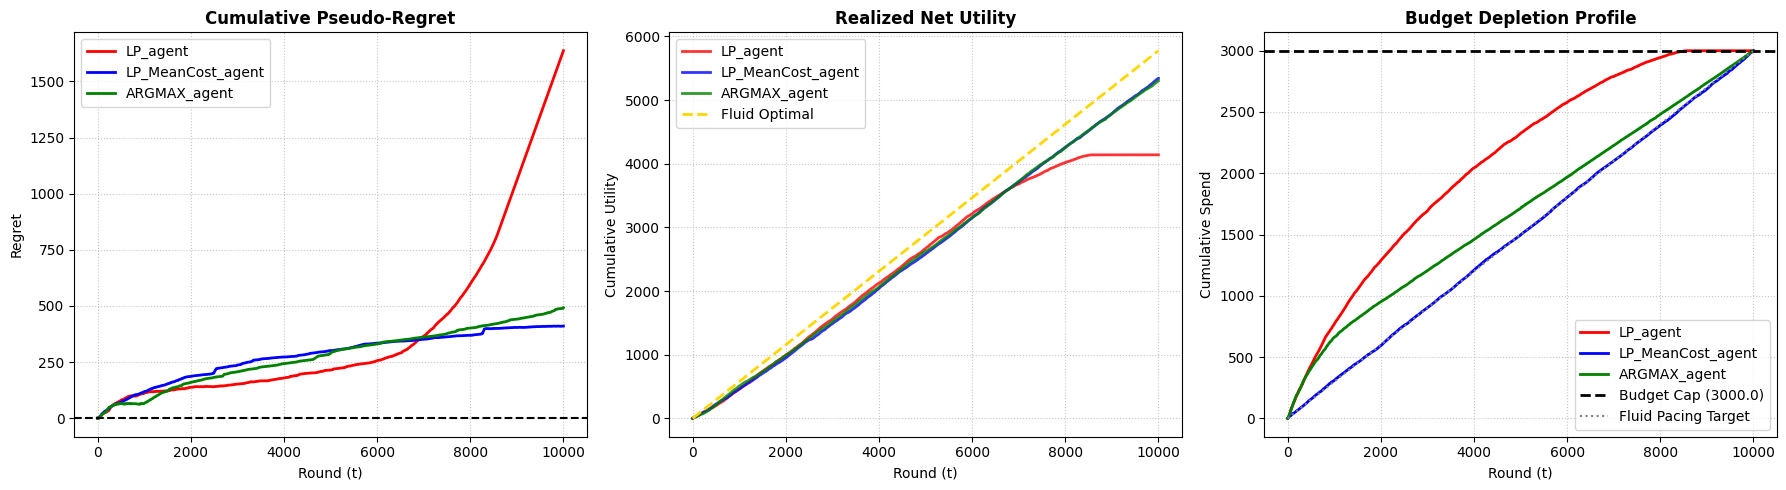


Agent                     | Final Pseudo-Regret  | Final Spend    
-----------------------------------------------------------------
LP_agent                  | 1636.79              | 2999.85/3000.00
LP_MeanCost_agent         | 410.38               | 2999.60/3000.00
ARGMAX_agent              | 491.63               | 2999.90/3000.00


In [25]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
from scipy import optimize
from scipy.stats import beta

from src.multi_campign_learners import LP_agent, LP_MeanCost_agent, ARGMAX_agent
from src.multi_campign_environments import MultiCampaignEnvironment

# ── 1. INSTANCE & DISTRIBUTION DEFINITION ────────────────────────────────────
VALUES         = [1, 0.8, 1.0]
BID_SPACE      = [0.0, 0.3, 0.6, 0.9, 0.1,0.75,1]
T              = 10000
B              = 0.3 * T  
COMPETITOR_MAX = 1
SEED           = 42

CONFLICT_MATRIX = [
    [False, True,  False],
    [True,  False, False],
    [False, False, False],
]

BETA_PARAMS = [(2, 5), (5, 2), (2, 2)]

def cdf_0(bids): return beta.cdf(np.clip(bids / COMPETITOR_MAX, 0.0, 1.0), 2, 5)
def cdf_1(bids): return beta.cdf(np.clip(bids / COMPETITOR_MAX, 0.0, 1.0), 5, 2)
def cdf_2(bids): return beta.cdf(np.clip(bids / COMPETITOR_MAX, 0.0, 1.0), 2, 2)
CDF_LIST = [cdf_0, cdf_1, cdf_2]

# ── 2. CLAIRVOYANT ORACLE ────────────────────────────────────────────────────
def compute_clairvoyant(values, bid_space, B, T, conflict_matrix, cdf_functions):
    values = np.array(values, dtype=float)
    bid_space = np.array(bid_space, dtype=float)
    N, K = len(values), len(bid_space)
    rho = float(B) / float(T)

    win_prob = np.zeros((N, K))
    for i in range(N):
        win_prob[i, :] = cdf_functions[i](bid_space)
    win_prob = np.clip(win_prob, 0.0, 1.0)

    mu_f = (values[:, None] - bid_space[None, :]) * win_prob
    mu_c = bid_space[None, :] * win_prob
    mu_f[:, 0] = 0.0
    mu_c[:, 0] = 0.0

    valid_per_campaign = [[k for k, b in enumerate(bid_space) if b <= values[i]] for i in range(N)]
    valid_arms = []
    for combo in itertools.product(*valid_per_campaign):
        conflict = False
        for i in range(N):
            for j in range(i + 1, N):
                if conflict_matrix[i][j] and combo[i] != 0 and combo[j] != 0:
                    conflict = True
                    break
            if conflict: break
        if not conflict: valid_arms.append(combo)

    super_arms = np.array(valid_arms, dtype=int)
    M = len(super_arms)
    idx = np.arange(N)[None, :]
    U_sa = np.sum(mu_f[idx, super_arms], axis=1)
    C_sa = np.sum(mu_c[idx, super_arms], axis=1)

    res = optimize.linprog(
        -U_sa, A_ub=C_sa.reshape(1, -1), b_ub=np.array([rho]),
        A_eq=np.ones((1, M)), b_eq=np.array([1.0]),
        bounds=[(0.0, 1.0)] * M, method='highs-ds'
    )
    
    if not res.success: raise ValueError("Fluid LP failed")
    gamma = np.clip(res.x, 0.0, 1.0)
    gamma /= gamma.sum()
    
    return gamma, super_arms, float(np.dot(gamma, U_sa))
# ── 3. SIMULATION LOOP ───────────────────────────────────────────────────────
if __name__ == "__main__":
    np.random.seed(SEED)
    _, _, opt_net_per_round = compute_clairvoyant(VALUES, BID_SPACE, B, T, CONFLICT_MATRIX, CDF_LIST)

    # CRN Master Sequence Generator
    def get_master_sequence(size):
        seq = np.zeros((size, len(VALUES)))
        for i in range(len(VALUES)):
            a, b_param = BETA_PARAMS[i]
            seq[:, i] = np.random.beta(a, b_param, size=size) * COMPETITOR_MAX
        return seq

    agents = {
        "LP_agent": LP_agent(VALUES, BID_SPACE, B, T, CONFLICT_MATRIX),
        "LP_MeanCost_agent": LP_MeanCost_agent(VALUES, BID_SPACE, B, T, CONFLICT_MATRIX),
        "ARGMAX_agent": ARGMAX_agent(VALUES, BID_SPACE, B, T, CONFLICT_MATRIX)
    }

    # Pass CDF_LIST directly to the environment
    envs = {
        name: MultiCampaignEnvironment(VALUES, B, T, get_master_sequence, CONFLICT_MATRIX, CDF_LIST)
        for name in agents
    }

    results = {name: {"pseudo_regret": np.zeros(T), "util": np.zeros(T), "spend": np.zeros(T)} for name in agents}
    print(f"Simulating T={T}. Evaluating...")

    # EXECUTION PHASE: Strictly encapsulated. No random draws or manual metric math.
    for t in range(T):
        for name, agent in agents.items():
            bids = agent.pull_arm()
            
            # The environment dictates absolute physical reality and mathematical tracking
            won_vector, util_vector, cost_vector, info = envs[name].resolve_auction(bids)
            
            agent.update(won_vector, util_vector, cost_vector)
            
            # Record metrics
            results[name]["pseudo_regret"][t] = opt_net_per_round - info["expected_net"]
            results[name]["util"][t] = np.sum(util_vector)
            results[name]["spend"][t] = envs[name].spent


    # ── 4. PLOTTING ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    rounds = np.arange(1, T + 1)
    colors = {
        "LP_agent": "red", 
        "LP_MeanCost_agent": "blue", 
        "ARGMAX_agent": "green"
    }

    for name in agents:
        axes[0].plot(rounds, np.cumsum(results[name]["pseudo_regret"]), color=colors[name], lw=2, label=name)
    axes[0].axhline(0, color='black', linestyle='--')
    axes[0].set_title("Cumulative Pseudo-Regret", fontweight='bold')
    axes[0].set_xlabel("Round (t)")
    axes[0].set_ylabel("Regret")
    axes[0].legend()
    axes[0].grid(True, linestyle=':', alpha=0.7)

    for name in agents:
        axes[1].plot(rounds, np.cumsum(results[name]["util"]), color=colors[name], lw=2, alpha=0.8, label=name)
    axes[1].plot(rounds, opt_net_per_round * rounds, color='gold', lw=2, linestyle='--', label="Fluid Optimal")
    axes[1].set_title("Realized Net Utility", fontweight='bold')
    axes[1].set_xlabel("Round (t)")
    axes[1].set_ylabel("Cumulative Utility")
    axes[1].legend()
    axes[1].grid(True, linestyle=':', alpha=0.7)

    for name in agents:
        axes[2].plot(rounds, results[name]["spend"], color=colors[name], lw=2, label=name)
    axes[2].axhline(B, color='black', lw=2, linestyle='--', label=f"Budget Cap ({B})")
    axes[2].plot(rounds, (B/T)*rounds, color='gray', lw=1.5, linestyle=':', label="Fluid Pacing Target")
    axes[2].set_title("Budget Depletion Profile", fontweight='bold')
    axes[2].set_xlabel("Round (t)")
    axes[2].set_ylabel("Cumulative Spend")
    axes[2].legend()
    axes[2].grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

    print(f"\n{'Agent':<25} | {'Final Pseudo-Regret':<20} | {'Final Spend':<15}")
    print("-" * 65)
    for name in agents:
        final_regret = np.sum(results[name]['pseudo_regret'])
        final_spend = results[name]['spend'][-1]
        print(f"{name:<25} | {final_regret:<20.2f} | {final_spend:.2f}/{B:.2f}")

## Remarks
